# Uniform Distance Voronoi and Delaunay Pattern Generator

This script demonstrates the generation of Voronoi and Delaunay patterns based on uniformly distributed points using Poisson Disk Sampling. The process involves the following steps:

1. **Poisson Disk Sampling + Lloyd optimization **:
    - A binary image is generated with points sampled using the Poisson Disk Sampling algorithm. This ensures that the points are uniformly distributed with a minimum distance between them.

2. **Pattern Generation**:
    - The sampled points are used to generate either a Voronoi diagram or a Delaunay triangulation. These patterns are created using the `scipy.spatial` library.

3. **Composite Image Creation**:
    - An RGB composite image is created to overlay the binary image, Voronoi pattern, and Delaunay pattern. Each pattern is assigned a specific color channel:
      - Red: Binary image (sampled points)
      - Green: Voronoi pattern
      - Blue: Delaunay pattern

4. **Visualization**:
    - The results are visualized using `matplotlib`. The following images are displayed:
      - The binary image with sampled points.
      - The cropped Voronoi pattern.
      - The cropped Delaunay pattern.
      - The RGB composite overlay of all patterns.

This script is useful for generating uniform distance patterns for applications such as computer graphics, simulations, and procedural content generation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.spatial import Voronoi, Delaunay
import torch
from scipy.spatial import cKDTree

def analyze_distribution(points, name="Distribution"):
    """
    각 점에 대해 가장 가까운 이웃과의 거리를 계산하여 평균과 분산을 출력합니다.
    """
    if len(points) < 2:
        return 0, 0

    # KDTree를 이용해 가장 가까운 2개의 점을 찾음 (첫 번째는 자기 자신이므로 거리가 0)
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=2)

    # 두 번째 열이 가장 가까운 이웃과의 거리
    nn_dists = dists[:, 1]

    mean_dist = np.mean(nn_dists)
    var_dist = np.var(nn_dists)
    std_dist = np.std(nn_dists)

    print(f"[{name}] N={len(points)}")
    print(f" - Nearest Neighbor Mean Dist: {mean_dist:.4f} px")
    print(f" - Variance: {var_dist:.4f}")
    print(f" - Std Dev:  {std_dist:.4f}")
    return mean_dist, var_dist

def optimize_lloyd_relaxation(points, domain_size, iterations=20):
    """
    Lloyd's relaxation algorithm (Centroidal Voronoi Tessellation).

    Standard algorithm for optimizing point distributions:
    1. For each point, find all pixels in its Voronoi region
    2. Move point to centroid of those pixels
    3. Repeat

    This converges to hexagonal packing with uniform spacing.
    """
    H, W = domain_size
    N = len(points)
    print(f"Optimization: N={N}, Lloyd's Relaxation ({iterations} iterations)")

    points = points.copy()

    for iteration in range(iterations):
        # Compute distance from each point to all other points
        tree = cKDTree(points)

        # For each point, find which pixels belong to its Voronoi region
        # Sample pixels densely to estimate regions
        grid_y, grid_x = np.mgrid[0:H:4, 0:W:4]  # Sample every 4th pixel for speed
        grid_pixels = np.column_stack((grid_x.ravel(), grid_y.ravel()))

        # Find nearest point for each pixel
        _, labels = tree.query(grid_pixels)

        # Compute centroid of each region
        new_points = np.zeros_like(points)
        for i in range(N):
            mask = labels == i
            if np.sum(mask) > 0:
                region_pixels = grid_pixels[mask]
                new_points[i] = np.mean(region_pixels, axis=0)
            else:
                # Point has no region - keep as is
                new_points[i] = points[i]

        # Update points with slight damping for stability
        damping = 0.5
        points = points * (1 - damping) + new_points * damping

        # Clamp to domain
        points[:, 0] = np.clip(points[:, 0], 0, W - 1)
        points[:, 1] = np.clip(points[:, 1], 0, H - 1)

    return points

def regular_grid_sampling(image_size, padWidth, min_dist):
    """
    Generates regular grid sampling points to evenly fill an image.

    Parameters:
        image_size (tuple): (height, width) of the image.
        min_dist (float): Required distance between points.

    Returns:
        image (ndarray): Binary image with sampled points.
    """
    height, width = image_size
    padh, padw = padWidth
    height += padh
    width += padw

    # Generate grid coordinates
    y_coords = np.arange(0, height, min_dist)
    x_coords = np.arange(0, width, min_dist)
    points = np.array(np.meshgrid(x_coords, y_coords)).reshape(2, -1).T

    # Create binary image with points
    image = np.zeros((height, width), dtype=np.uint8)
    for pt in points:
        x, y = int(pt[0]), int(pt[1])
        if 0 <= x < width and 0 <= y < height:
            image[y, x] = 255  # Mark point in the image

    return image

def poisson_disk_sampling_fixed(image_size, padWidth, min_dist, k=30):
    """
    Generates Poisson Disk Sampling points to evenly fill an image.
    
    Parameters:
        image_size (tuple): (height, width) of the image.
        padWidth (tuple): (pad_h, pad_w) - Padding to add to the sampling area.
        min_dist (float): Required distance between points.
        k (int): Maximum attempts before rejection.

    Returns:
        image (ndarray): Binary image with sampled points (0 or 255).
    """
    h_in, w_in = image_size
    pad_h, pad_w = padWidth
    
    # Sampling 영역의 전체 크기 계산
    total_height = h_in + pad_h
    total_width = w_in + pad_w

    cell_size = min_dist / np.sqrt(2)
    
    # Grid Shape: (Rows, Cols) -> (Height 방향 개수, Width 방향 개수)
    grid_rows = int(np.ceil(total_height / cell_size))
    grid_cols = int(np.ceil(total_width / cell_size))
    
    # Grid 초기화 (-1: empty)
    grid = -np.ones((grid_rows, grid_cols), dtype=int)
    
    points = []
    process_list = []

    def get_grid_indices(pt):
        """
        Point (x, y)를 받아 Grid의 (row_idx, col_idx)를 반환
        pt[0] = x (width 방향), pt[1] = y (height 방향)
        """
        gx = int(pt[0] / cell_size)  # Col index
        gy = int(pt[1] / cell_size)  # Row index
        
        # Boundary protection (float 연산 오차 방지)
        gx = min(max(gx, 0), grid_cols - 1)
        gy = min(max(gy, 0), grid_rows - 1)
        
        return gy, gx  # (Row, Col) 순서로 반환

    def is_valid(pt):
        # 1. 전체 영역 벗어나는지 확인
        if not (0 <= pt[0] < total_width and 0 <= pt[1] < total_height):
            return False
        
        # 2. Grid 기반 이웃 검사
        gy, gx = get_grid_indices(pt) # (Row, Col) 로 받음
        
        # 주변 5x5 그리드 셀 확인
        for dy in range(-2, 3):
            for dx in range(-2, 3):
                ny, nx = gy + dy, gx + dx
                
                # Grid 범위 체크
                if 0 <= ny < grid_rows and 0 <= nx < grid_cols:
                    neighbor_idx = grid[ny, nx]
                    if neighbor_idx != -1: # 이미 점이 있는 경우
                        neighbor = points[neighbor_idx]
                        dist_sq = (pt[0] - neighbor[0])**2 + (pt[1] - neighbor[1])**2
                        if dist_sq < min_dist**2: # 거리 조건 위배
                            return False
        return True

    # 1. Start with a random point
    # 초기 포인트를 전체 영역 내에서 랜덤하게 선정
    first_pt = np.array([np.random.uniform(0, total_width), np.random.uniform(0, total_height)])
    
    points.append(first_pt)
    process_list.append(first_pt)
    
    gy, gx = get_grid_indices(first_pt)
    grid[gy, gx] = 0  # index of the first point

    # 2. Main Loop
    while process_list:
        idx = np.random.randint(len(process_list))
        base_pt = process_list[idx]
        found = False
        
        for _ in range(k):
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.uniform(min_dist, 2 * min_dist)
            
            # New candidate point
            new_pt = base_pt + radius * np.array([np.cos(angle), np.sin(angle)])
            
            if is_valid(new_pt):
                points.append(new_pt)
                process_list.append(new_pt)
                
                gy, gx = get_grid_indices(new_pt)
                grid[gy, gx] = len(points) - 1
                found = True
                break
        
        if not found:
            process_list.pop(idx)

    # 3. Create Output Image
    # padWidth를 포함한 전체 크기로 만들지, 원본 크기로 crop할지에 따라 다르지만,
    # 보통 padding 영역은 경계면 artifact 방지용이므로 최종 output은 요청한 size(total)로 맞춥니다.
    image = np.zeros((total_height, total_width), dtype=np.uint8)
    
    for pt in points:
        x, y = int(pt[0]), int(pt[1])
        if 0 <= x < total_width and 0 <= y < total_height:
            image[y, x] = 255

    return image
def generate_pattern_with_canvas(binary_image, pattern_type="voronoi"):
    """
    Generates a Voronoi or Delaunay pattern without spatial constraints and then crops to the canvas.

    Parameters:
        binary_image (ndarray): Binary image where white pixels are sample points.
        pattern_type (str): "voronoi" for Voronoi diagram, "delaunay" for Delaunay triangulation.
        canvas (tuple): (x0, y0, width, height) defining the cropping region.
        padding (int): Extra space around the canvas for better edge completion.

    Returns:
        cropped_output (ndarray): Cropped image containing the final pattern within the canvas.
    """
    sY, sX = (binary_image.shape[0], binary_image.shape[1])

    # Extract points from the binary image
    points = np.column_stack(np.where(binary_image > 0))  # (y, x) format

    if len(points) < 3:
        raise ValueError("Not enough sample points detected. Ensure the binary image has enough white points.")

    # Create an extended output canvas
    output = np.zeros((sY, sX), dtype=np.uint8)

    if pattern_type.lower() == "voronoi":
        vor = Voronoi(points)

        for simplex in vor.ridge_vertices:
            if -1 in simplex:
                continue  # Ignore infinite edges

            pt1, pt2 = vor.vertices[simplex]
            pt1, pt2 = tuple(map(int, pt1)), tuple(map(int, pt2))

            # Draw the edges only if they are within the extended canvas
            # if (0 <= pt1[0] < extended_height and 0 <= pt1[1] < extended_width) and \
            #    (0 <= pt2[0] < extended_height and 0 <= pt2[1] < extended_width):
            cv2.line(output, (pt1[1], pt1[0]), (pt2[1], pt2[0]), 255, 1)

    elif pattern_type.lower() == "delaunay":
        tri = Delaunay(points)

        for simplex in tri.simplices:
            pts = points[simplex]
            pt1, pt2, pt3 = tuple(map(tuple, pts))

            # Ensure points are inside extended bounds before drawing
            # if all(0 <= pt[0] < extended_height and 0 <= pt[1] < extended_width for pt in [pt1, pt2, pt3]):
            cv2.line(output, (pt1[1], pt1[0]), (pt2[1], pt2[0]), 255, 1)
            cv2.line(output, (pt2[1], pt2[0]), (pt3[1], pt3[0]), 255, 1)
            cv2.line(output, (pt3[1], pt3[0]), (pt1[1], pt1[0]), 255, 1)

    else:
        raise ValueError("Invalid pattern type. Choose 'voronoi' or 'delaunay'.")

    # Crop back to the original canvas region
    cropped_output = output[0:sY, 0:sX]

    return cropped_output

# Function to create an RGB composite image overlaying binary, Voronoi, and Delaunay images
def create_composite_image(binary_image, voronoi_pattern, delaunay_pattern):
    binary_image = (binary_image > 0).astype(np.uint8)
    voronoi_pattern = (voronoi_pattern > 0).astype(np.uint8)
    delaunay_pattern = (delaunay_pattern > 0).astype(np.uint8)

    composite = np.zeros((*binary_image.shape, 3), dtype=np.uint8)

    composite[:, :, 0] = binary_image * 255
    composite[:, :, 1] = voronoi_pattern * 255
    composite[:, :, 2] = delaunay_pattern * 255

    return composite

def mmNormalize(data):
    if isinstance(data, torch.Tensor):
        data = (data - torch.min(data)) / (torch.max(data) - torch.min(data)+1e-6)
    else:
        data = (data - np.min(data)) / (np.max(data) - np.min(data)+1e-6)

    # noise term prevents the zero division
    return data

def save8bitImg(fileName, toSave, scaling=True):
    if scaling==True:
        toSave = mmNormalize(toSave)
        toSave = np.array(toSave*255, dtype='uint8')
    else:
        toSave =  np.array(toSave, dtype='uint8')

    return cv2.imwrite(f'{fileName}',toSave)


In [6]:
um = 1e-6
mm = 1e-3
pxSize = 2.7*um
nMat = 1.53
maxHeight = 10*um

# img_size = (1600, 2400)
img_size = (1600, 2560)

fLength = 1.12*mm
regular_grid = False

ROC = fLength*(nMat-1)

maxRadius = np.sqrt(max(ROC*ROC - (ROC -maxHeight)**2, 0.0)) / 2

if regular_grid == True:
    maxDistPx = (maxRadius / pxSize) * (np.sqrt(2)) 
else:
    maxDistPx =(maxRadius / pxSize) * (np.sqrt(3))

min_dist = int(1.2*maxDistPx) # Minimum distance between points

# min_dist = 90

padWidth = (min_dist*4, min_dist*4)  # Extra padding around the image
print(f"# maxDistPx :{maxDistPx}")

# maxDistPx :34.801021696368586


Generating Poisson Disk Sampling (Initialization)...
[Before Optimization] N=1866
 - Nearest Neighbor Mean Dist: 44.2490 px
 - Variance: 11.6630
 - Std Dev:  3.4151
Running Lloyd's Relaxation Optimization...
Optimization: N=1866, Lloyd's Relaxation (10 iterations)
[After Optimization] N=1866
 - Nearest Neighbor Mean Dist: 47.6568 px
 - Variance: 11.9956
 - Std Dev:  3.4635


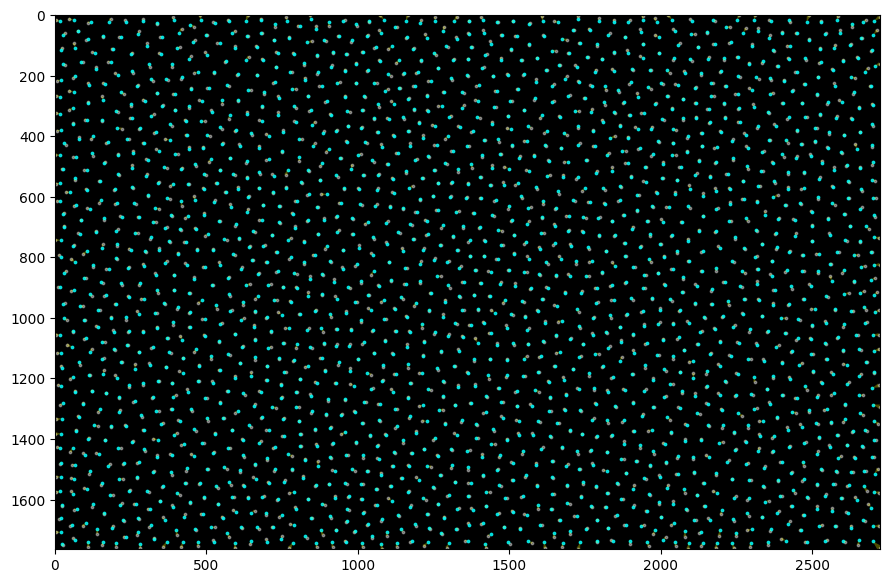

Generating Patterns...


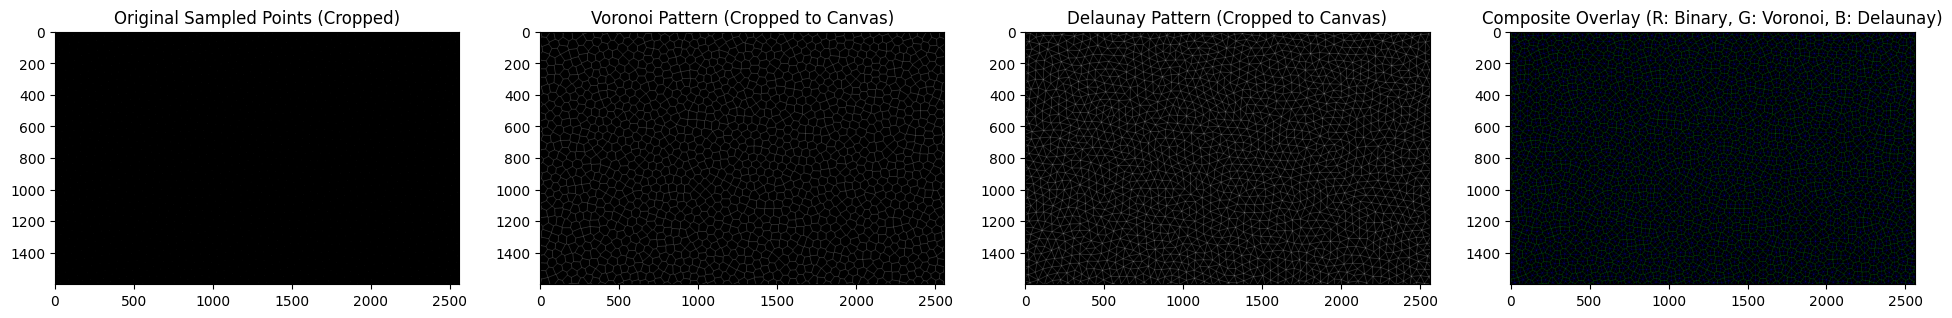

(1600, 2560)


True

In [7]:

full_height = img_size[0] + padWidth[0]
full_width = img_size[1] + padWidth[1]

# Create a binary image with randomly sampled points
if regular_grid == True:
    binary_image_padded = regular_grid_sampling(img_size, padWidth, min_dist)
else:
    print("Generating Poisson Disk Sampling (Initialization)...")
    temp_image = poisson_disk_sampling_fixed(img_size, padWidth, min_dist, k=40)
    # 1. 초기 샘플링 (Poisson Disk) - FIXED version without dist_variance constraint
    # temp_image = poisson_disk_sampling_fixed(img_size, padWidth, min_dist, k=30)

    # 2. 좌표 추출 (y, x) -> (x, y)
    y_idxs, x_idxs = np.where(temp_image > 0)
    initial_points = np.column_stack((x_idxs, y_idxs)).astype(np.float32)

    # [분석 1] 최적화 전 분포 확인
    analyze_distribution(initial_points, name="Before Optimization")

    # 3. 최적화 수행 (Lloyd's Relaxation)
    print("Running Lloyd's Relaxation Optimization...")
    optimized_points = optimize_lloyd_relaxation(
        initial_points,
        domain_size=(full_height, full_width),
        iterations=10
    )

    # [분석 2] 최적화 후 분포 확인
    analyze_distribution(optimized_points, name="After Optimization")

    # 4. 최적화된 좌표로 이미지 다시 그리기 (Re-painting)
    binary_image_padded = np.zeros((full_height, full_width), dtype=np.uint8)
    for pt in optimized_points:
        x, y = int(pt[0]), int(pt[1])
        if 0 <= x < full_width and 0 <= y < full_height:
            binary_image_padded[y, x] = 255

    # 5. 시각화 (Scatter Plot으로 변경하여 점이 잘 보이도록 함)
    # imshow는 고해상도에서 1px 점을 뭉개버리므로 scatter가 적합합니다.
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_facecolor('black')

    ax.scatter(initial_points[:, 0], initial_points[:, 1],
            s=3, c='white', alpha=0.4)

    ax.scatter(optimized_points[:, 0], optimized_points[:, 1],
            s=3, c='cyan', alpha=0.8)

    # displacement vectors
    ax.quiver(
        initial_points[:, 0], initial_points[:, 1],
        optimized_points[:, 0] -  initial_points[:, 0],
        optimized_points[:, 1] - initial_points[:, 1],
        angles='xy', scale_units='xy', scale=1,   # ✅ 핵심
        pivot='tail',
        color='yellow', alpha=0.3, linewidth=0.5)
    ax.set_xlim(0, full_width)
    ax.set_ylim(full_height, 0)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


print("Generating Patterns...")
# Convert binary image into Voronoi or Delaunay pattern
voronoi_pattern = generate_pattern_with_canvas(binary_image_padded, pattern_type="voronoi")
delaunay_pattern = generate_pattern_with_canvas(binary_image_padded, pattern_type="delaunay")
composite_image = create_composite_image(binary_image_padded, voronoi_pattern, delaunay_pattern)

# Cropping
voronoi_pattern = voronoi_pattern[min_dist:img_size[0]+min_dist, min_dist:img_size[1]+min_dist]
delaunay_pattern = delaunay_pattern[min_dist:img_size[0]+min_dist, min_dist:img_size[1]+min_dist]
binary_image_padded = binary_image_padded[min_dist:img_size[0]+min_dist, min_dist:img_size[1]+min_dist]
composite_image = composite_image[min_dist:img_size[0]+min_dist, min_dist:img_size[1]+min_dist]


# Plot all results including the RGB composite
fig, ax = plt.subplots(1, 4, figsize=(24, 6))

ax[0].imshow(binary_image_padded, cmap='gray')
ax[0].set_title("Original Sampled Points (Cropped)")

ax[1].imshow(voronoi_pattern, cmap='gray')
ax[1].set_title("Voronoi Pattern (Cropped to Canvas)")

ax[2].imshow(delaunay_pattern, cmap='gray')
ax[2].set_title("Delaunay Pattern (Cropped to Canvas)")

ax[3].imshow(composite_image)
ax[3].set_title("Composite Overlay (R: Binary, G: Voronoi, B: Delaunay)")
plt.show()

distInMicron = int((min_dist*pxSize)/um)
print(voronoi_pattern.shape)
save8bitImg(f'r[{regular_grid}]_Voronoi{img_size[0]}_dist{min_dist}px.png',voronoi_pattern)
save8bitImg(f'r[{regular_grid}]_Dot{img_size[0]}_dist{min_dist}px.png',binary_image_padded)
# save8bitImg(f'r[{regular_grid}]_Delaunay{img_size[0]}_dist{min_dist}px.png',delaunay_pattern)
# save8bitImg(f'r[{regular_grid}]_Composite{img_size[0]}_dist{min_dist}px.png',composite_image)

## Reaction–Diffusion (Gray–Scott) Phase Mask (DMD → Sensor)

- **Task 1**: Generate a **2560×1600** binary/grayscale Turing-like pattern with target average worm width 

  - target width 

    - **20 µm** (physical)
    - **≈ 7.4 px** on DMD (2.7 µm pitch)

- **Task 2**: Map DMD pattern to sensor grid (IMX708, 1.4 µm pitch) assuming **1:1 magnification** in real space.

- **Verification**: show full images, **200×200 center crops**, and **2D FFT power spectra**; estimate average worm width via distance transform + thinning skeleton.

In [ ]:
# If you run this notebook in a fresh environment, install dependencies once.
# (Safe to re-run; pip will skip already-installed packages.)
import sys

# Uncomment if needed:
# !{sys.executable} -m pip install -U numpy scipy matplotlib opencv-python


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

# -----------------------------
# Hardware specs (given)
# -----------------------------
DMD_W, DMD_H = 2560, 1600
DMD_PITCH_UM = 2.7

SENSOR_W, SENSOR_H = 4608, 2592
SENSOR_PITCH_UM = 1.4

TARGET_WORM_WIDTH_UM = 20.0
TARGET_WORM_WIDTH_PX_DMD = TARGET_WORM_WIDTH_UM / DMD_PITCH_UM  # ~7.407 px


# -----------------------------
# Utility: fast 5-point Laplacian (periodic BC)
# -----------------------------
def laplacian_5pt(x: np.ndarray) -> np.ndarray:
    return (
        -4.0 * x
        + np.roll(x, 1, axis=0)
        + np.roll(x, -1, axis=0)
        + np.roll(x, 1, axis=1)
        + np.roll(x, -1, axis=1)
    )


# -----------------------------
# Gray-Scott reaction-diffusion
# -----------------------------
def gray_scott(
    shape_hw,
    Du=0.16,
    Dv=0.08,
    F=0.035,
    k=0.065,
    dt=1.0,
    steps=2000,
    seed=0,
    init_square=True,
    noise=0.02,
    dtype=np.float32,
):
    """Return (u, v) fields as float arrays in [~0,1]."""
    rng = np.random.default_rng(seed)
    H, W = shape_hw

    u = np.ones((H, W), dtype=dtype)
    v = np.zeros((H, W), dtype=dtype)

    # standard initialization: a small perturbation region
    if init_square:
        h0, h1 = int(H * 0.45), int(H * 0.55)
        w0, w1 = int(W * 0.45), int(W * 0.55)
        u[h0:h1, w0:w1] = 0.50
        v[h0:h1, w0:w1] = 0.25

    u += (noise * (rng.random((H, W)) - 0.5)).astype(dtype)
    v += (noise * (rng.random((H, W)) - 0.5)).astype(dtype)

    # main loop
    for _ in range(steps):
        Lu = laplacian_5pt(u)
        Lv = laplacian_5pt(v)

        uvv = u * v * v
        du = Du * Lu - uvv + F * (1.0 - u)
        dv = Dv * Lv + uvv - (F + k) * v

        u = u + dt * du
        v = v + dt * dv

        # mild numerical safety
        np.clip(u, 0.0, 1.0, out=u)
        np.clip(v, 0.0, 1.0, out=v)

    return u, v


# -----------------------------
# Zhang-Suen thinning (skeletonization) for 0/1 uint8 images
# -----------------------------
def zhang_suen_thinning(bin01: np.ndarray, max_iters=200) -> np.ndarray:
    """Return skeleton (uint8 0/1). Input must be 0/1."""
    img = (bin01.astype(np.uint8)).copy()
    H, W = img.shape

    def neighbors(x):
        P2 = np.roll(x, -1, axis=0)
        P3 = np.roll(np.roll(x, -1, axis=0), 1, axis=1)
        P4 = np.roll(x, 1, axis=1)
        P5 = np.roll(np.roll(x, 1, axis=0), 1, axis=1)
        P6 = np.roll(x, 1, axis=0)
        P7 = np.roll(np.roll(x, 1, axis=0), -1, axis=1)
        P8 = np.roll(x, -1, axis=1)
        P9 = np.roll(np.roll(x, -1, axis=0), -1, axis=1)
        return P2, P3, P4, P5, P6, P7, P8, P9

    for _ in range(max_iters):
        prev = img.copy()
        P2, P3, P4, P5, P6, P7, P8, P9 = neighbors(img)
        N = P2 + P3 + P4 + P5 + P6 + P7 + P8 + P9
        A = (
            ((P2 == 0) & (P3 == 1)).astype(np.uint8)
            + ((P3 == 0) & (P4 == 1)).astype(np.uint8)
            + ((P4 == 0) & (P5 == 1)).astype(np.uint8)
            + ((P5 == 0) & (P6 == 1)).astype(np.uint8)
            + ((P6 == 0) & (P7 == 1)).astype(np.uint8)
            + ((P7 == 0) & (P8 == 1)).astype(np.uint8)
            + ((P8 == 0) & (P9 == 1)).astype(np.uint8)
            + ((P9 == 0) & (P2 == 1)).astype(np.uint8)
        )

        m1 = (img == 1) & (N >= 2) & (N <= 6) & (A == 1) & ((P2 * P4 * P6) == 0) & ((P4 * P6 * P8) == 0)
        img[m1] = 0

        P2, P3, P4, P5, P6, P7, P8, P9 = neighbors(img)
        N = P2 + P3 + P4 + P5 + P6 + P7 + P8 + P9
        A = (
            ((P2 == 0) & (P3 == 1)).astype(np.uint8)
            + ((P3 == 0) & (P4 == 1)).astype(np.uint8)
            + ((P4 == 0) & (P5 == 1)).astype(np.uint8)
            + ((P5 == 0) & (P6 == 1)).astype(np.uint8)
            + ((P6 == 0) & (P7 == 1)).astype(np.uint8)
            + ((P7 == 0) & (P8 == 1)).astype(np.uint8)
            + ((P8 == 0) & (P9 == 1)).astype(np.uint8)
            + ((P9 == 0) & (P2 == 1)).astype(np.uint8)
        )

        m2 = (img == 1) & (N >= 2) & (N <= 6) & (A == 1) & ((P2 * P4 * P8) == 0) & ((P2 * P6 * P8) == 0)
        img[m2] = 0

        if np.array_equal(img, prev):
            break

    # remove periodic wrap artifacts by zeroing borders (safer for measurements)
    img[0, :] = 0
    img[-1, :] = 0
    img[:, 0] = 0
    img[:, -1] = 0
    return img


# -----------------------------
# Width estimation: distance transform + skeleton average radius
# -----------------------------
def estimate_worm_width_px(binary_mask_01: np.ndarray) -> float:
    """Estimate average thickness (px) of foreground 'worms'."""
    fg = (binary_mask_01.astype(np.uint8) * 255)
    if fg.sum() == 0:
        return float('nan')

    # distance transform inside foreground
    dist = cv2.distanceTransform(fg, distanceType=cv2.DIST_L2, maskSize=3)

    skel = zhang_suen_thinning((fg > 0).astype(np.uint8))
    vals = dist[skel > 0]
    if vals.size < 50:
        return float('nan')

    # width ~ 2 * radius
    return float(2.0 * np.mean(vals))


# -----------------------------
# Quick tuning on a smaller patch by scaling diffusion
# (scaling Du,Dv ~ (effective dx)^2)
# -----------------------------
def tune_diffusion_scale(
    target_width_px,
    base_params,
    patch_hw=(512, 512),
    steps=1500,
    scales=(0.25, 0.5, 1.0, 2.0, 4.0),
    seed=0,
):
    best = None
    for s in scales:
        Du = base_params['Du'] * (s ** 2)
        Dv = base_params['Dv'] * (s ** 2)
        u, v = gray_scott(
            patch_hw,
            Du=Du,
            Dv=Dv,
            F=base_params['F'],
            k=base_params['k'],
            dt=base_params['dt'],
            steps=steps,
            seed=seed,
        )
        patt = v
        thr = float(np.mean(patt))
        bw = (patt > thr).astype(np.uint8)
        wpx = estimate_worm_width_px(bw)
        err = abs(wpx - target_width_px) if np.isfinite(wpx) else np.inf
        cand = dict(scale=s, Du=Du, Dv=Dv, width_px=wpx, err=err)
        if (best is None) or (cand['err'] < best['err']):
            best = cand
        print(f"[tune] scale={s:>4}  width≈{wpx:6.2f} px  err={err:6.2f}")
    return best


# -----------------------------
# DMD -> Sensor mapping (1:1 in real space)
# -----------------------------
def map_dmd_to_sensor(dmd_img: np.ndarray) -> np.ndarray:
    """Resample by physical pitch ratio and center-crop/pad to sensor size."""
    scale = DMD_PITCH_UM / SENSOR_PITCH_UM  # ~1.9286

    H, W = dmd_img.shape
    newW = int(np.round(W * scale))
    newH = int(np.round(H * scale))

    # OpenCV expects (W,H)
    resized = cv2.resize(dmd_img.astype(np.float32), (newW, newH), interpolation=cv2.INTER_LINEAR)

    out = np.zeros((SENSOR_H, SENSOR_W), dtype=np.float32)

    # if resized is larger: crop center
    if newH >= SENSOR_H:
        y0 = (newH - SENSOR_H) // 2
        y1 = y0 + SENSOR_H
        src_y0, src_y1 = y0, y1
        dst_y0, dst_y1 = 0, SENSOR_H
    else:
        dst_y0 = (SENSOR_H - newH) // 2
        dst_y1 = dst_y0 + newH
        src_y0, src_y1 = 0, newH

    if newW >= SENSOR_W:
        x0 = (newW - SENSOR_W) // 2
        x1 = x0 + SENSOR_W
        src_x0, src_x1 = x0, x1
        dst_x0, dst_x1 = 0, SENSOR_W
    else:
        dst_x0 = (SENSOR_W - newW) // 2
        dst_x1 = dst_x0 + newW
        src_x0, src_x1 = 0, newW

    out[dst_y0:dst_y1, dst_x0:dst_x1] = resized[src_y0:src_y1, src_x0:src_x1]
    return out


# -----------------------------
# Visualization helpers
# -----------------------------
def center_crop(img: np.ndarray, size=200) -> np.ndarray:
    H, W = img.shape
    y0 = H // 2 - size // 2
    x0 = W // 2 - size // 2
    return img[y0:y0 + size, x0:x0 + size]


def fft_power(img: np.ndarray, out_hw=(1024, 1024)) -> np.ndarray:
    """FFT power spectrum (log) on a resized copy for speed."""
    Ht, Wt = out_hw
    small = cv2.resize(img.astype(np.float32), (Wt, Ht), interpolation=cv2.INTER_AREA)
    F = np.fft.fftshift(np.fft.fft2(small))
    P = np.abs(F) ** 2
    return np.log10(P + 1e-6)


# =============================================================
# Run: Generate DMD pattern (Gray-Scott) with thickness tuning
# =============================================================
base = dict(Du=0.16, Dv=0.08, F=0.035, k=0.065, dt=1.0)
print(f"Target worm width on DMD: {TARGET_WORM_WIDTH_PX_DMD:.2f} px  (~{TARGET_WORM_WIDTH_UM:.1f} µm)")

best = tune_diffusion_scale(
    target_width_px=TARGET_WORM_WIDTH_PX_DMD,
    base_params=base,
    patch_hw=(512, 512),
    steps=1500,
    scales=(0.25, 0.5, 1.0, 2.0, 4.0),
    seed=1,
)
print("\nBest scale candidate:", best)

Du_tuned, Dv_tuned = best['Du'], best['Dv']

# Full-resolution simulation (can take a while)
U, V = gray_scott(
    (DMD_H, DMD_W),
    Du=Du_tuned,
    Dv=Dv_tuned,
    F=base['F'],
    k=base['k'],
    dt=base['dt'],
    steps=2200,
    seed=2,
)

# Grayscale pattern on DMD
pattern_dmd = V.astype(np.float32)
pattern_dmd = (pattern_dmd - pattern_dmd.min()) / (pattern_dmd.max() - pattern_dmd.min() + 1e-9)

# Binary mask for thickness measurement (simple adaptive threshold by mean)
thr = float(np.mean(pattern_dmd))
binary_dmd = (pattern_dmd > thr).astype(np.uint8)

width_px = estimate_worm_width_px(binary_dmd)
width_um = width_px * DMD_PITCH_UM
print(f"\n[Width estimate] {width_px:.2f} px  ->  {width_um:.2f} µm (target {TARGET_WORM_WIDTH_UM:.2f} µm)")

# =============================================================
# Task 2: Map to sensor grid (1:1 physical)
# =============================================================
pattern_sensor = map_dmd_to_sensor(pattern_dmd)

# =============================================================
# Visualization: full, center crop, FFT
# =============================================================
dmd_crop = center_crop(pattern_dmd, 200)
sensor_crop = center_crop(pattern_sensor, 200)

fft_dmd = fft_power(pattern_dmd, out_hw=(1024, 1024))
fft_sensor = fft_power(pattern_sensor, out_hw=(1024, 1024))

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

ax[0, 0].imshow(pattern_dmd, cmap='gray')
ax[0, 0].set_title("(a) DMD pattern (2560×1600)")
ax[0, 0].axis('off')

ax[0, 1].imshow(pattern_sensor, cmap='gray')
ax[0, 1].set_title("(b) Sensor-mapped pattern (4608×2592)")
ax[0, 1].axis('off')

ax[0, 2].imshow(dmd_crop, cmap='gray')
ax[0, 2].set_title("(c-1) DMD center 200×200")
ax[0, 2].axis('off')

ax[1, 0].imshow(sensor_crop, cmap='gray')
ax[1, 0].set_title("(c-2) Sensor center 200×200")
ax[1, 0].axis('off')

ax[1, 1].imshow(fft_dmd, cmap='magma')
ax[1, 1].set_title("(d-1) FFT power (DMD, resized)")
ax[1, 1].axis('off')

ax[1, 2].imshow(fft_sensor, cmap='magma')
ax[1, 2].set_title("(d-2) FFT power (Sensor, resized)")
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Output arrays (requested)
pattern_dmd_2d = pattern_dmd  # 2D numpy array (H=1600, W=2560)
pattern_sensor_2d = pattern_sensor  # 2D numpy array (H=2592, W=4608)
print("\nArrays ready:")
print("- pattern_dmd_2d:", pattern_dmd_2d.shape, pattern_dmd_2d.dtype)
print("- pattern_sensor_2d:", pattern_sensor_2d.shape, pattern_sensor_2d.dtype)
